![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [5]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.3
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [6]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1: Esta es una medida la cual ayuda saber que tanto tarda el sistema en acceder al inicio de un bloque de datos en el disco para que este pueda empezar a enviar su informacion
- Respuesta 2: Este representa que tantos datos se pueden enviar en un cierto tiempo, y esto refleja la velocidad de lectura del dispositivo, normalmente se mide en MiB/s
- Respuesta 3: Esto se hace debido a que en el acceso secuencial los datos se encuentran muy cercanos entre si, por lo que el disco se posiciona en un dato y luego se va moviendo o leyendo, lo que aproxima este M a 1
- Respuesta 4: Al contrario que el secuencial, cada lectura ocurre en una posicion distinta del disco por eso aleatorio, por lo que indica muchos accesos, aumentando el valor de M

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [7]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 1024

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 1024
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1: El tamaño elegido en mi caso fue de 1GB, ya que en mi equipo hay 16gb de ram, por lo que queria evitar que se estuviera leyendo el cache de la ram
- Respuesta 2: Pues yo espero que el ultimo bloque de 256Kb tenga el mejor rendimiento en acceso aleatorio, debido a que entre mas tamaño se leen mas datos en cada operacion y con eso reduccir el numero de accesos a este 
- Respuesta 3: En mi caso se hara desde el editor de codigo VsCode en mi equipo local

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [8]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = True  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

Carpeta io_lab_data eliminada. El archivo se recreará en la siguiente sección.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [9]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 1024 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 1073741824


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1: Este archivo lo que hace es simular los datos almacenados en el disco.
- Respuesta 2: Esto es dependiendo cuanta Ram haya en el sistema, es util trabajar con un archivo grande debido a que evita que la medicion sea en el disco y no en el cache de la Ram
- Respuesta 3: Si el archivo fuera muy pequeño lo que pasaria es que el s.o lo almacenaria completamente en el cache de la memoria ram, por lo que las mediciones no se estarian haciendo desde el disco si no desde la propia ram, generando resultados que no serian los que buscamos

## 5. Funciones auxiliares de medición

In [10]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [11]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 1.5699 s, throughput: 652.26 MiB/s
Aleatorio  -> tiempo: 0.0503 s, throughput: 310.42 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.5352 s, throughput: 1913.20 MiB/s
Aleatorio  -> tiempo: 0.0526 s, throughput: 1187.26 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.2948 s, throughput: 3473.73 MiB/s
Aleatorio  -> tiempo: 0.1205 s, throughput: 2073.84 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.2350 s, throughput: 4356.81 MiB/s
Aleatorio  -> tiempo: 0.2740 s, throughput: 3649.77 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,1073741824,262144,1.569916,652.264239,4.0
1,Aleatorio,4096,16384000,4000,0.050336,310.415868,4.0
2,Secuencial,16384,1073741824,65536,0.535228,1913.204775,16.0
3,Aleatorio,16384,65536000,4000,0.052642,1187.260413,16.0
4,Secuencial,65536,1073741824,16384,0.294784,3473.731096,64.0
5,Aleatorio,65536,262144000,4000,0.120549,2073.838611,64.0
6,Secuencial,262144,1073741824,4096,0.235034,4356.812751,256.0
7,Aleatorio,262144,1048576000,4000,0.273990,3649.770905,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta
1. En mi caso fue el acceso secuencial en todos los tamaños de bloque
2. Si, este fue aumentando al aumentar el tamaño del bloque, por ejemplo el acceso secuencial el primer bloque tuvo un throughput de 652.26 MiB/s y el ultimo bloque un throughput de 4356.81 MiB/s, de forma similar el aleatorio de 310.42 MiB/s a 3649.77 MiB/s, lo que nos ayuda a concluir de que se aprovecha mejor el disco al trabajar con bloques grandes
3. La mayor diferencia notable fue en el bloque de 4 Kb ya que el acceso secuencial duplico y hasta mas al aleatorio, pasando de 310.42 MiB/s a 652.26 MiB/s

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [12]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe
- Latencia asumida: 10 µs
- Throughput asumido: 5 GB/s

Este modelo teorico se asemeja al de un SSD convencional, sin embargo, son condiciones perfectas y no se tienen encuenta como sistema operativo, carga de CPU o alguna carga extra, por lo que es una buena aproximacion pero no es perfecta


In [13]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.200010,5119.744013
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.200010,5119.744013
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.200010,5119.744013
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.200010,5119.744013
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [21]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,1073741824,262144,1.569916,652.264239,4.0,0.200010,5119.744013,7.849187,0.127402
1,Aleatorio,4096,16384000,4000,0.050336,310.415868,4.0,0.043052,362.935239,1.169190,0.855293
2,Secuencial,16384,1073741824,65536,0.535228,1913.204775,16.0,0.200010,5119.744013,2.676004,0.373691
3,Aleatorio,16384,65536000,4000,0.052642,1187.260413,16.0,0.052207,1197.156753,1.008335,0.991733
4,Secuencial,65536,1073741824,16384,0.294784,3473.731096,64.0,0.200010,5119.744013,1.473846,0.678497
5,Aleatorio,65536,262144000,4000,0.120549,2073.838611,64.0,0.088828,2814.423923,1.357108,0.736861
6,Secuencial,262144,1073741824,4096,0.235034,4356.812751,256.0,0.200010,5119.744013,1.175112,0.850983
7,Aleatorio,262144,1048576000,4000,0.273990,3649.770905,256.0,0.235313,4249.667995,1.164366,0.858837


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta
1. En mi caso los tiempos empiricos (elapsed_s) fueron mayores que los teoricos (theoretical_elapsed_s), por ejemplo en el acceso de 4Kb el empirico fue de 1.57s aprox y el del teorico fue de 0.2s, por lo que la estimacion se aleja a lo que realmente se refleja
2. Pues en todos los casos fue mas aproximado el acceso aleatorio, y el mejor de los casos fue el de 16Kb, en el throughput empirico me dio un valor de 1187.260413	MiB/s, con un tiempo de 0.052, y con el teorico el throughput me dio 1197.156753 MiB/s y con un tiempo de 0.052, son casi iguales en ambos casos, en cambio en el acceso secuencial si se puede observar mas disparejo
3. Estas diferencias pueden ser causadas por factores de la vida real que esten afectando el sistema, como puede ser la cache del sistema operativo (este puede afectar las lecturas), tambien la carga de la CPU que tan ocupada este, puede afectar los resultados, tambien una temperatura alta en la CPU hace mas lento a este porque al estar con mucha carga este busca enfriarse, y por ultimo los resultados pueden ser afectados por el tipo de disco, un NVMe siempre sera superior a un HDD por la velocidad de lectura tan diferente que hay entre estos


## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [15]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\user\Desktop\2026-1\Estructura_de_Datos\repositorios\lab3-IO_performance-EstebanTobon\images


Guardada: fig_throughput.png


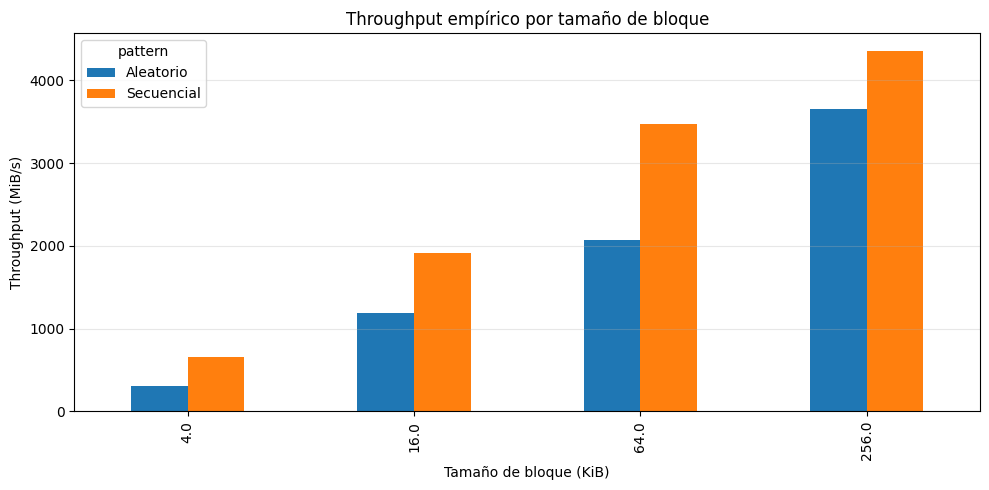

In [16]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta
- Según la gráfica, las barras más altas son las de acceso secuencial, como anteriormente se había dicho. Se puede notar que el valor en 16 KB es el de mayor diferencia (1913.20 MiB/s secuencial vs 1187.26 MiB/s aleatorio). Mirando solo la gráfica podemos ver que con el acceso aleatorio el throughput es de más de 1000 MiB/s, y con el acceso secuencial el valor del throughput es de casi 2000 MiB/s.
- En términos de rendimiento, significa que hay una mejora en la lectura de datos en el throughput. En el acceso secuencial se refleja con el aumento del tamaño del bloque: mientras que en el bloque de 4 KB la velocidad es menor a 1000 MiB/s (652.26 MiB/s), en el bloque de 256 KB el throughput es de más de 4000 MiB/s (4356.81 MiB/s), por lo que se refleja una gran mejora de rendimiento. Lo mismo pasa con el acceso aleatorio, que pasa de menos de 500 MiB/s (310.42 MiB/s) hasta casi 4000 MiB/s (3649.77 MiB/s).
- Con todo lo analizado anteriormente, podemos afirmar que el acceso secuencial tuvo un mejor rendimiento. Como dijimos anteriormente, pasó de menos de 1000 MiB/s a más de 4000 MiB/s (652.26 → 4356.81 MiB/s), y tiene sentido, ya que el acceso secuencial reduce la cantidad de accesos al disco y, por lo tanto, permite envíos de datos más continuos.


Guardada: fig_tiempo_empirico.png


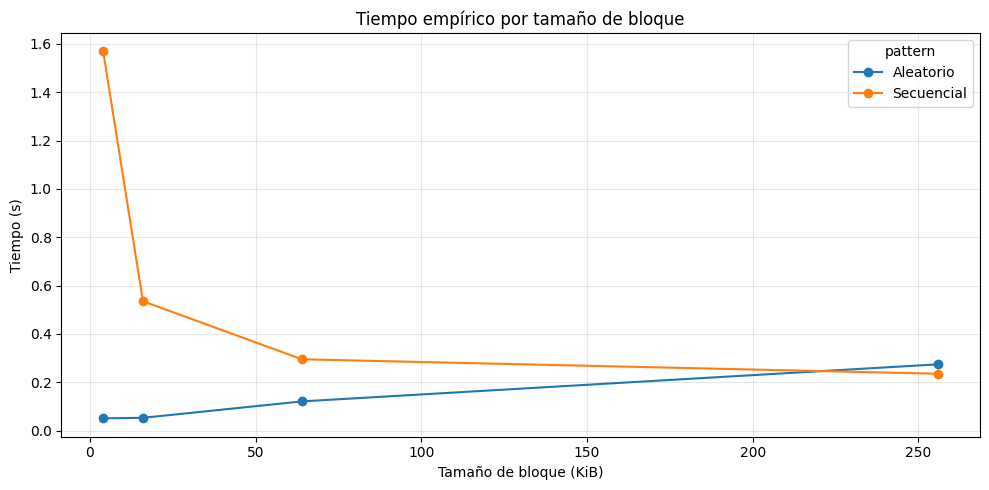

In [17]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

Mirando la grafica podemos ver tres cosas en general:
- El acceso secuencia es el que mas tiempo de acceso tiene de los dos, este empieza desde 1.6s en el bloque de 4Kb, pero a medida de que el tiempo va pasando podemos observar que el tiempo disminuye hasta que llega aproximadamente a 0.23s lo que muetsra una mejora significativa
- En el acceso aleatorio podemos ver que tiene un tiempo de acceso muy bajo como menos de 0.1s pero al aumentar el valor de los bloques este tiempo empeora lo contrario a lo secuencial, hasta llegar a un valor de 0.25s aprox, empeorando el del secuencial
- Comparando ambas curvas se observa una gran divergencia en el tiempo en el bloque de 4Kb, lo que uno diria que el secuencial es mejor, pero no porque lo que vimos anteriormente tiene un throughput peor que el secuencial, e incluso esa diferencia se cierra en los bloques de 256Kb, donde el acceso secuencial gana en tiempo y en throughput al aleatorio 

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


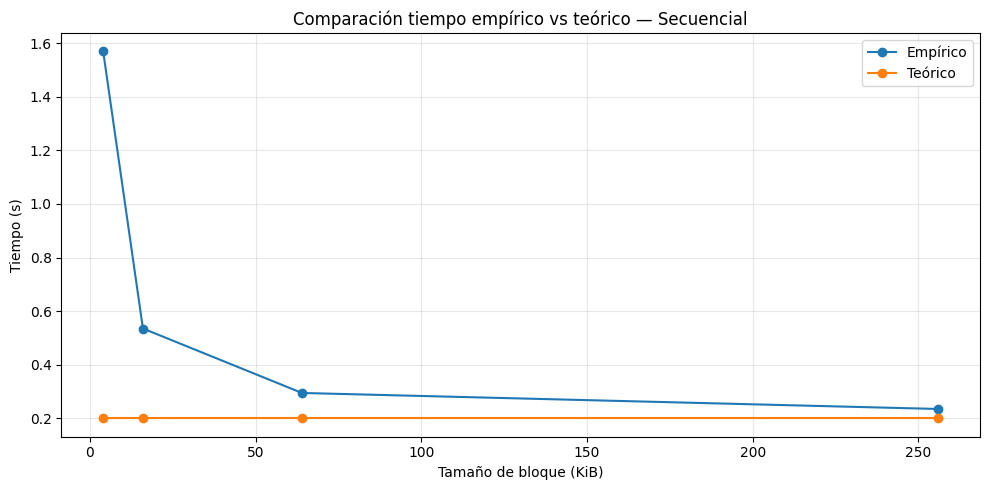

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


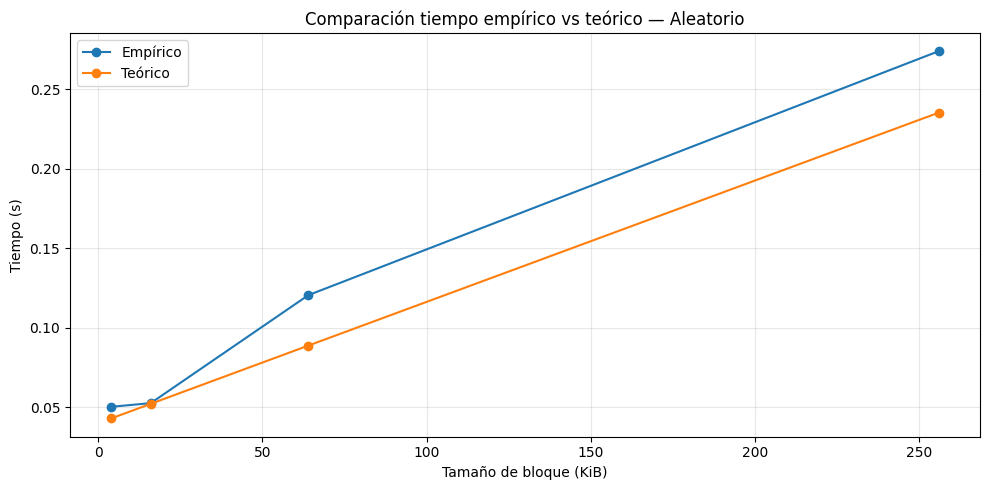

In [18]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

1. Viendo la gráfica, sí tienen una tendencia similar, sobre todo en el acceso aleatorio. En este se puede observar que, aunque al inicio es algo irregular, después del bloque de 4 KB las curvas empiezan a verse más similares. En el acceso secuencial, al principio no tienen una tendencia similar, de hecho se observa una divergencia grande, pero al igual que en el aleatorio, después del bloque de 4 KB se estabiliza y la similitud aumenta
2. En el acceso secuencial, el punto donde hay mayor separación es al inicio, en el bloque de 4 KB, donde el empírico está alrededor de 1.5 s y el teórico en 0.2 s. Por otro lado, en el acceso aleatorio se observa que a partir del bloque de 16 KB las curvas comienzan a separarse, siendo la mayor diferencia visible en el bloque de 256 KB aproximadamente
3. Esto sugiere que el modelo subestima el tiempo real, es decir, los tiempos teóricos están por debajo de lo que realmente ocurre. Esto sucede porque el modelo es muy simple y no tiene en cuenta factores reales como la caché del sistema operativo, la carga del sistema o la latencia real del hardware, lo que hace que los tiempos medidos sean mayores

Guardada: fig_speedup.png


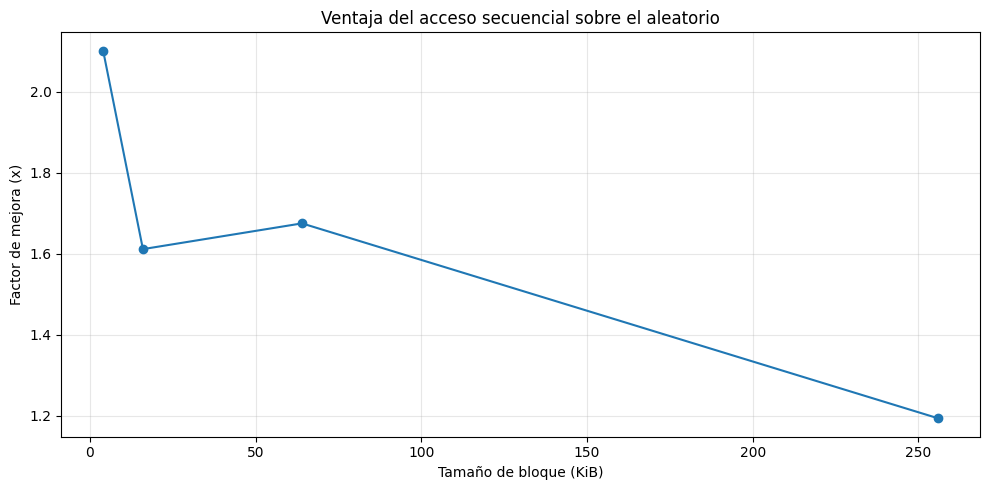

In [19]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

- Mirando la grafica el mejor factor de mejora fue en el bloque de 4Kb, haciendo hasta mas de un x2.1  con respector al otro (652.26 MiB/s vs 310.42 MiB/s)
- Esta ventaja no se mantiene siempre, va bajando con el aumento del tamaño del bloque, como por ejemplo en el bloque de 256Kb se tiene un rendimiento en el acceso casi igual, la ventaja de uno sobre otro es de 1.2 aproximadamente
- Esto implica que a la hora de diseñar un software es mejor manejar un acceso secuencial ya que en teoria siempre sera superior al aleatorio, especialmente cuando se trabajan con bloques pequeños, sin embargo en bloques grandes la diferencia no es tan notable, pero en mi criterio siempre sera mejor trabajar con acceso secuencial

## 10. Resumen automático de resultados

In [20]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,1.569916,0.050336,652.264239,310.415868,2.101259
1,16.0,0.535228,0.052642,1913.204775,1187.260413,1.611445
2,64.0,0.294784,0.120549,3473.731096,2073.838611,1.675025
3,256.0,0.235034,0.273990,4356.812751,3649.770905,1.193722


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

En conclusion en este laboratorio se pudo observar de que la informacion en un disco se almacena en bloques, y esto importa debido a que el sistema lee los datos completos y no bytes individuales, lo que afecta directamente el rendimiento. Ahora bien mirando los resultados obtenidos apartir de un disco SSD NVMe, se evidencio que el acceso secuencial es superior al aleatorio en todos los bloques testeados, se tienen comportamientos muy distintos

En los resultados obtenidos podemos ver que el acceso secuencial alcanzo un throughput de 4356.812751	MiB/s en el bloque mas grande que es el de 256Kb, mientras que el aleatorio llego hasta 3649.770905 MibB/s, y el mayor factor de mejora respecto el secuencial al aleatorio fue en el bloque de 4Kb con una mejora de 2.1, lo que podemos ver el mejor rendimiento de el acceso secuencial sobre el aleatorio

Ahora bien, el modelo teorico tuvo sus pequeños errores porque idealizaba todo no tenia encuenta factores externos, por lo que sobre todo en el tiempo fue bastante diferente, subestimo el tiempo de ejecucion empirico, el tiempo teorico que daba el modelo era de 0.20s aproximadamente en un bloque de 4Kb, pero a la hora de la verdad fue otra, me dio un valor de 1.52s en realidad, por lo que si comparamos valores, estos son muy diferentes, pero a medida del aumento del tamaño de bloques la verdad si se acerco el tiempo de ejecucion en ambos accesos como pudimos ver en las graficas anteriores

Ya para finalizar, en base a resultados el diseño de un sistema deberia centrarse en el uso de accesos secuenciales, siempre y cuando sea posible, ya que esto permite un mejor rendimiento y aunque el tiempo de accesos no sea el mejor lo compensa el throughput

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.